# Figure 4 | Genetic basis of variation in unproductive splicing

Panels for **Figure 4**, matching the manuscript caption lettering.

| Panel | File | What it shows |
|---|---|---|
| **a** | `fig4A` | p-sQTL and u-sQTL counts across GTEx tissues at 10% FDR |
| **b** | `fig4B_usQTL`, `fig4B_psQTL` | eQTL vs sQTL effect size in cultured fibroblasts (483 donors) |
| **c** | `fig4C` | The same comparison summarized across all 49 GTEx tissues |
| **d** | `fig4D` | Percentage of GWAS loci colocalizing with a u-sQTL, 19 traits |
| **e** | `fig4E_sQTL`, `fig4E_eQTL`, `fig4E_ASB16` | ASB16 u-sQTL colocalizing with bipolar disorder (rs7212573) |
| **f** | `fig4F` | LocusCompare plots for GWAS, eQTL and u-sQTL at ASB16 |

`fig4_colocs_sc2` is also produced but is **not** a Figure 4 panel.

Run **cell 3** once to build (and pickle) all plot-ready data, then the plot
cells. On later sessions, uncomment **cell 2** and skip cell 3 to re-plot from
`figure_data/` without recomputing anything.

Markdown cells carry the **final figure legends** for the panels that report
statistics; the code cell after each prints the numbers those legends quote.
`run_all` also writes `figure_data/fig4C_source_data.tsv` (Supplementary Table 9)
and `figure_data/fig4D_source_data.tsv` (Supplementary Table 10).

Panel names changed to match the caption: `fig4B` -> `fig4C`, `fig4B1` ->
`fig4B_usQTL`, `fig4B2` -> `fig4B_psQTL`, `fig4D2_coloc` -> `fig4D`,
`fig4_coloc_example_*_colored` -> `fig4E_*`, `fig4_ASB16` -> `fig4E_ASB16`.
The original `savefig` paths are kept commented in each cell.

In [1]:
import importlib
import os

from matplotlib import pyplot as plt

import Figure4_plot_helpers
import Figure4_helpers
importlib.reload(Figure4_plot_helpers)
importlib.reload(Figure4_helpers)

from Figure4_plot_helpers import (plot_fig4A, plot_fig4C, plot_beta_scatter,
                                  plot_fig4D, plot_genotype_boxplot,
                                  plot_isoform_annotations,
                                  plot_fig4F_locuscompare)
from Figure4_helpers import (run_all, load_plot_data, format_stats_report,
                             PLOTS_DIR,
                             ASB16_GENE)   # gene id for the fig4E_ASB16 model

# Vector output. Keep text as editable text, not outlined shapes:
#   svg.fonttype='none' -> matplotlib emits <text> elements naming the font
#                          instead of converting each glyph to a <path>, so
#                          Inkscape opens them as editable text objects.
#   pdf.fonttype=42     -> embeds TrueType rather than Type 3, keeping text
#                          selectable and editable in PDF editors too.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

os.makedirs(PLOTS_DIR, exist_ok=True)
print('panels will be written to', PLOTS_DIR)


def unrasterize():
    """Clear every rasterization flag on the current figure, before savefig.

    The plot helpers pass rasterized=True to their scatter/strip layers, which
    is right for screen but not for the vector deliverable. Walking
    fig.findobj() and calling set_rasterized(False) turns that off without
    editing Figure4_plot_helpers.py.
    """
    fig = plt.gcf()
    for artist in fig.findobj():
        if hasattr(artist, 'set_rasterized'):
            try:
                artist.set_rasterized(False)
            except Exception:
                pass
    for ax in fig.axes:
        ax.set_rasterization_zorder(None)
    return fig

panels will be written to /project/yangili1/cfbuenabadn/leafcutter2_paper/analysis/Figure4/plots


In [2]:
# Fast path: re-plot straight from the pickles written by run_all().
# Uncomment this cell and skip the next one.

# data = load_plot_data('figure_data')

# fig4A_data            = data['fig4A_data']
# fig4C_data            = data['fig4C_data']
# fig4C_source_data     = data['fig4C_source_data']
# fig4B_usQTL_fit            = data['fig4B_usQTL_fit']
# fig4B_psQTL_fit            = data['fig4B_psQTL_fit']
# fig4B_usQTL_stats          = data['fig4B_usQTL_stats']
# fig4B_psQTL_stats          = data['fig4B_psQTL_stats']
# fig4_colocs_sc2_fit      = data['fig4_colocs_sc2_fit']
# fig4D_data           = data['fig4D_data']
# fig4D_stats          = data['fig4D_stats']
# fig4E_sQTL_boxplot_df = data['fig4E_sQTL_boxplot_df']
# fig4E_eQTL_boxplot_df = data['fig4E_eQTL_boxplot_df']
# fig4E_ASB16_annot           = data['fig4E_ASB16_annot']
# fig4F_data            = data['fig4F_data']
# fig4E_sQTL_stats      = data['fig4E_sQTL_stats']
# fig4E_eQTL_stats      = data['fig4E_eQTL_stats']
# fig4E_sQTL_box_stats  = data['fig4E_sQTL_box_stats']
# fig4E_eQTL_box_stats  = data['fig4E_eQTL_box_stats']

In [3]:
# Full data pipeline: reads the per-tissue sQTL count and correlation tables,
# recomputes the fibroblast sQTL-vs-eQTL betas, builds the hyprcoloc GWAS
# percentages, and pulls the ASB16 genotypes, phenotypes, nominal QTL statistics
# and exon annotation. Pickles every plot-ready variable into figure_data/ and
# writes fig4C_source_data.tsv and fig4D_source_data.tsv there. Only heavy cell.

data = run_all('figure_data')

fig4A_data            = data['fig4A_data']
fig4C_data            = data['fig4C_data']
fig4C_source_data     = data['fig4C_source_data']
fig4B_usQTL_fit            = data['fig4B_usQTL_fit']
fig4B_psQTL_fit            = data['fig4B_psQTL_fit']
fig4B_usQTL_stats          = data['fig4B_usQTL_stats']
fig4B_psQTL_stats          = data['fig4B_psQTL_stats']
fig4_colocs_sc2_fit      = data['fig4_colocs_sc2_fit']
fig4D_data           = data['fig4D_data']
fig4D_stats          = data['fig4D_stats']
fig4E_sQTL_boxplot_df = data['fig4E_sQTL_boxplot_df']
fig4E_eQTL_boxplot_df = data['fig4E_eQTL_boxplot_df']
fig4E_ASB16_annot           = data['fig4E_ASB16_annot']
fig4F_data            = data['fig4F_data']
fig4E_sQTL_stats      = data['fig4E_sQTL_stats']
fig4E_eQTL_stats      = data['fig4E_eQTL_stats']
fig4E_sQTL_box_stats  = data['fig4E_sQTL_box_stats']
fig4E_eQTL_box_stats  = data['fig4E_eQTL_box_stats']

100%|██████████| 49/49 [00:20<00:00,  2.42it/s]


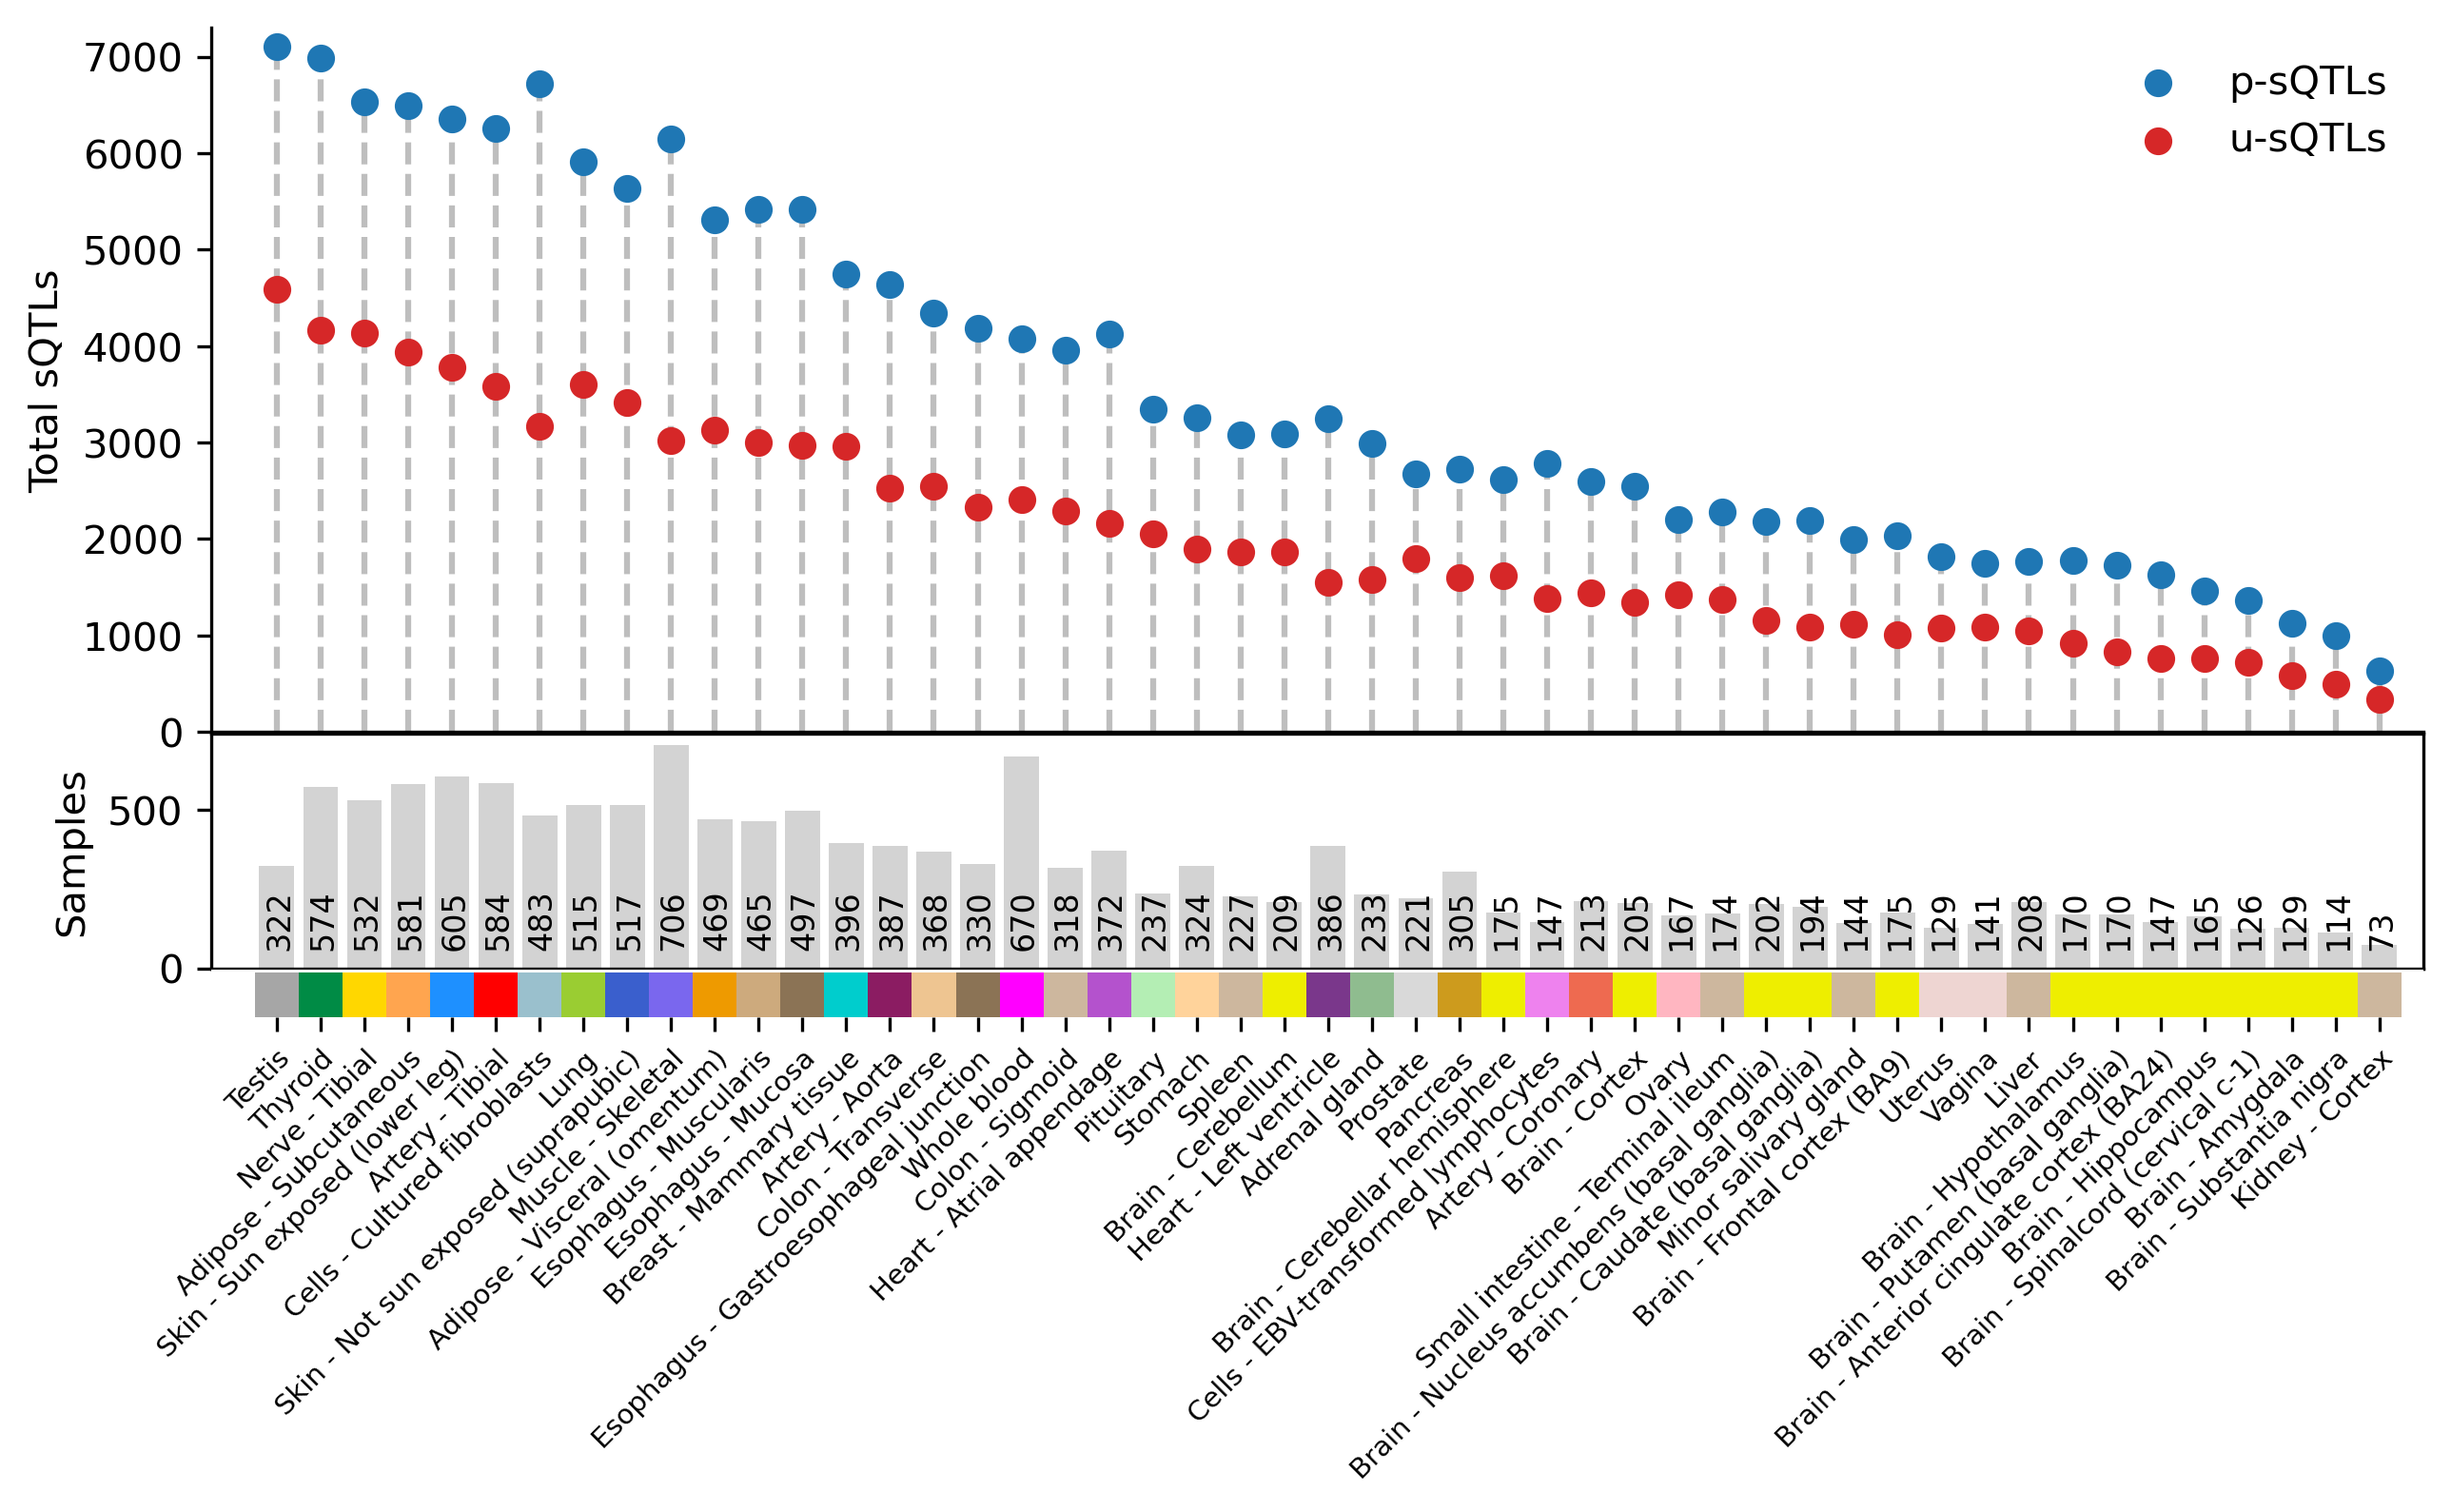

In [4]:
# Fig. 4a | fig4A -- from QTL_analysis.ipynb
# Number of productive (p-sQTL) and unproductive (u-sQTL) sQTLs identified
# across GTEx tissues at 10% FDR, with per-tissue donor counts beneath.

plot_fig4A(fig4A_data)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4A.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4A.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4A.svg', dpi=300, bbox_inches='tight')

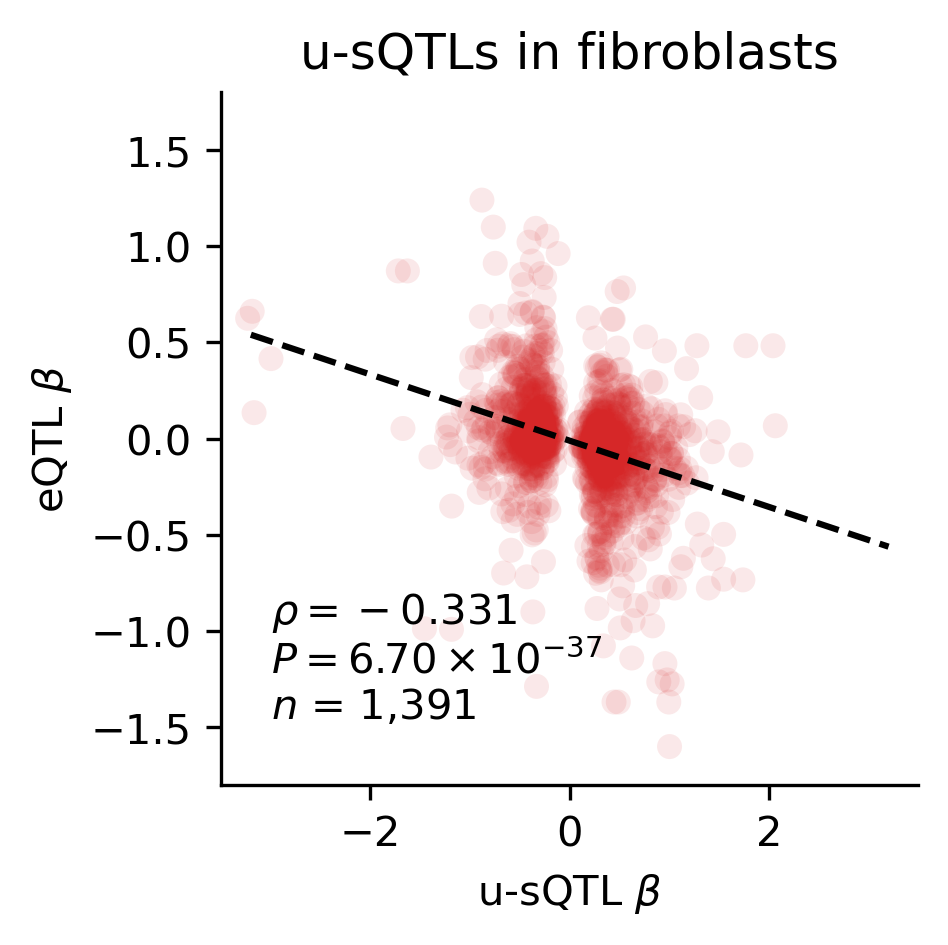

In [5]:
# Fig. 4b (left) | fig4B_usQTL -- from QTL_analysis.ipynb  (was named fig4B1)
# eQTL vs u-sQTL effect size in cultured fibroblasts from 483 donors,
# n = 1,391 unproductive introns. Alleles that increase unproductive splicing
# tend to decrease expression of the host gene. Dashed line, least-squares
# linear fit. Two-sided Spearman rank correlation, no adjustment for multiple
# comparisons as each panel is a single test.

plot_beta_scatter(
    fig4B_usQTL_fit,
    color='tab:red',
    xlim=[-3.5, 3.5],
    ylim=[-1.8, 1.8],
    text=r'$\rho = -0.33$' + '\np-val $< 1e^{-36}$',   # original, superseded by stats=
    stats=fig4B_usQTL_stats,
    text_xy=(-3, -1.5),
    xlabel=r'u-sQTL $\beta$',
    ylabel=r'eQTL $\beta$',
    title='u-sQTLs in fibroblasts',
    line='ols',
    band=None,
)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.svg', dpi=300, bbox_inches='tight')

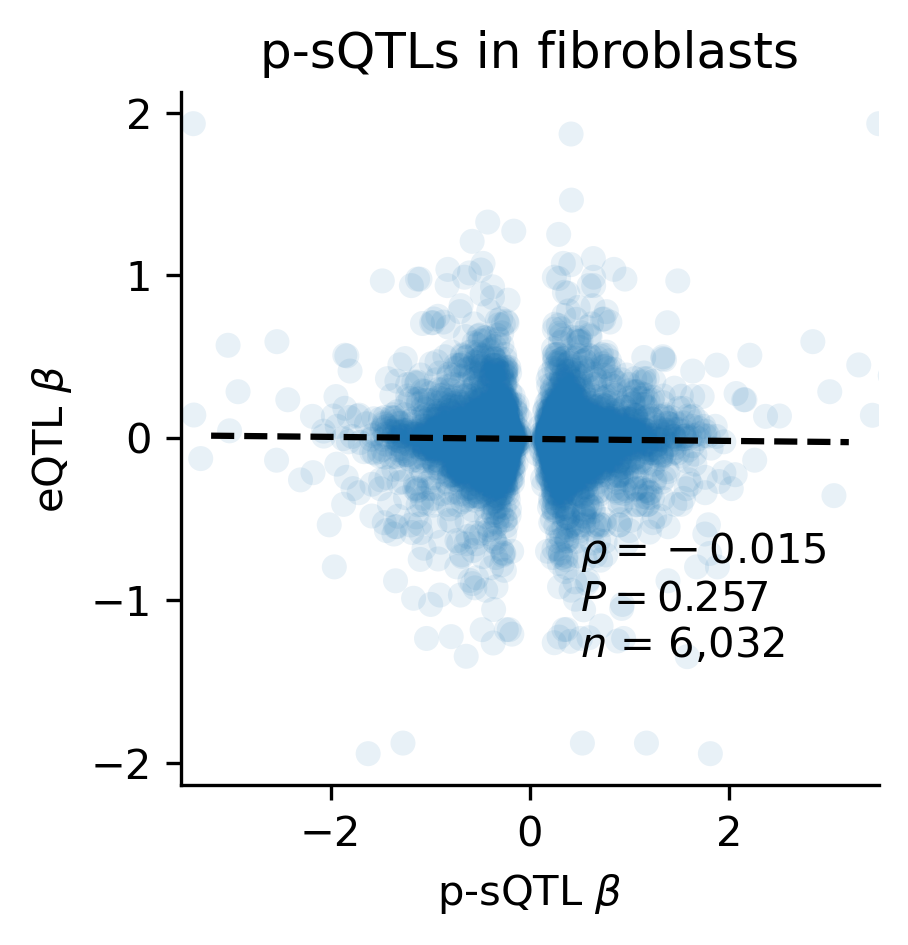

In [6]:
# Fig. 4b (right) | fig4B_psQTL -- from QTL_analysis.ipynb  (was named fig4B2)
# The p-sQTL half of panel b: same 483 donors, n = 6,032 productive introns.
# Productive splicing shows no comparable coupling to host-gene expression,
# which is what makes the u-sQTL panel interpretable.

plot_beta_scatter(
    fig4B_psQTL_fit,
    color='tab:blue',
    xlim=[-3.5, 3.5],
    ylim=None,
    text=r'$\rho = -0.015$' + '\np-val $= 0.26$',   # original, superseded by stats=
    stats=fig4B_psQTL_stats,
    text_xy=(0.5, -1.4),
    xlabel=r'p-sQTL $\beta$',
    ylabel=r'eQTL $\beta$',
    title='p-sQTLs in fibroblasts',
    line='ols',
    band=None,
)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4B_psQTL.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4B_psQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4B_psQTL.svg', dpi=300, bbox_inches='tight')

**Fig. 4b legend.** Effect of each sQTL on intron excision (β, *x* axis)
against its effect on host-gene expression (β, *y* axis) in GTEx cultured
fibroblasts, from n = 483 donors; donors are biological replicates, each
contributing one primary culture, one library and one genotype, with no
technical replication. Each point is one intron–variant–gene triplet, not a
replicate: **b1**, n = 1,391 unproductive introns; **b2**, n = 6,032 productive
introns, which serve as the negative control for b1. Dashed line, least-squares
linear fit; no error band is shown. Association was tested by two-sided Spearman
rank correlation, without adjustment for multiple comparisons as each panel is a
single test: **b1**, ρ = −0.331 (95% CI −0.378 to −0.282), *t*(1,389) = −13.07,
*P* = 6.70 × 10⁻³⁷; **b2**, ρ = −0.015 (95% CI −0.040 to 0.011),
*t*(6,030) = −1.13, *P* = 0.257.

In [7]:
# fig4B_usQTL / fig4B_psQTL reporting -- the numbers quoted in the legend above.
for tag, st in [('fig4B1 (u-sQTLs)', fig4B_usQTL_stats), ('fig4B2 (p-sQTLs)', fig4B_psQTL_stats)]:
    lo, hi = st['ci95']
    print(f"{tag}: n = {st['n']} triplets, {st['n_donors']} donors | "
          f"rho = {st['rho']:.3f} (95% CI {lo:.3f} to {hi:.3f}) | "
          f"t({st['df']}) = {st['t']:.2f} | P = {st['pvalue']:.3g}")
    blo, bhi = st['ci95_boot']
    print(f"    bootstrap 95% CI {blo:.3f} to {bhi:.3f} (should match the Fisher-z CI)")
    print(f"    OLS slope (dashed line) = {st['ols']['slope']:.4f}, "
          f"95% CI [{st['ols']['ci95'][0]:.4f}, {st['ols']['ci95'][1]:.4f}], "
          f"P = {st['ols']['pvalue']:.3g}")

fig4B1 (u-sQTLs): n = 1391 triplets, 483 donors | rho = -0.331 (95% CI -0.378 to -0.282) | t(1389) = -13.07 | P = 6.7e-37
    bootstrap 95% CI -0.381 to -0.280 (should match the Fisher-z CI)
    OLS slope (dashed line) = -0.1720, 95% CI [-0.1975, -0.1465], P = 1.01e-37
fig4B2 (p-sQTLs): n = 6032 triplets, 483 donors | rho = -0.015 (95% CI -0.040 to 0.011) | t(6030) = -1.13 | P = 0.257
    bootstrap 95% CI -0.041 to 0.012 (should match the Fisher-z CI)
    OLS slope (dashed line) = -0.0062, 95% CI [-0.0156, 0.0032], P = 0.197


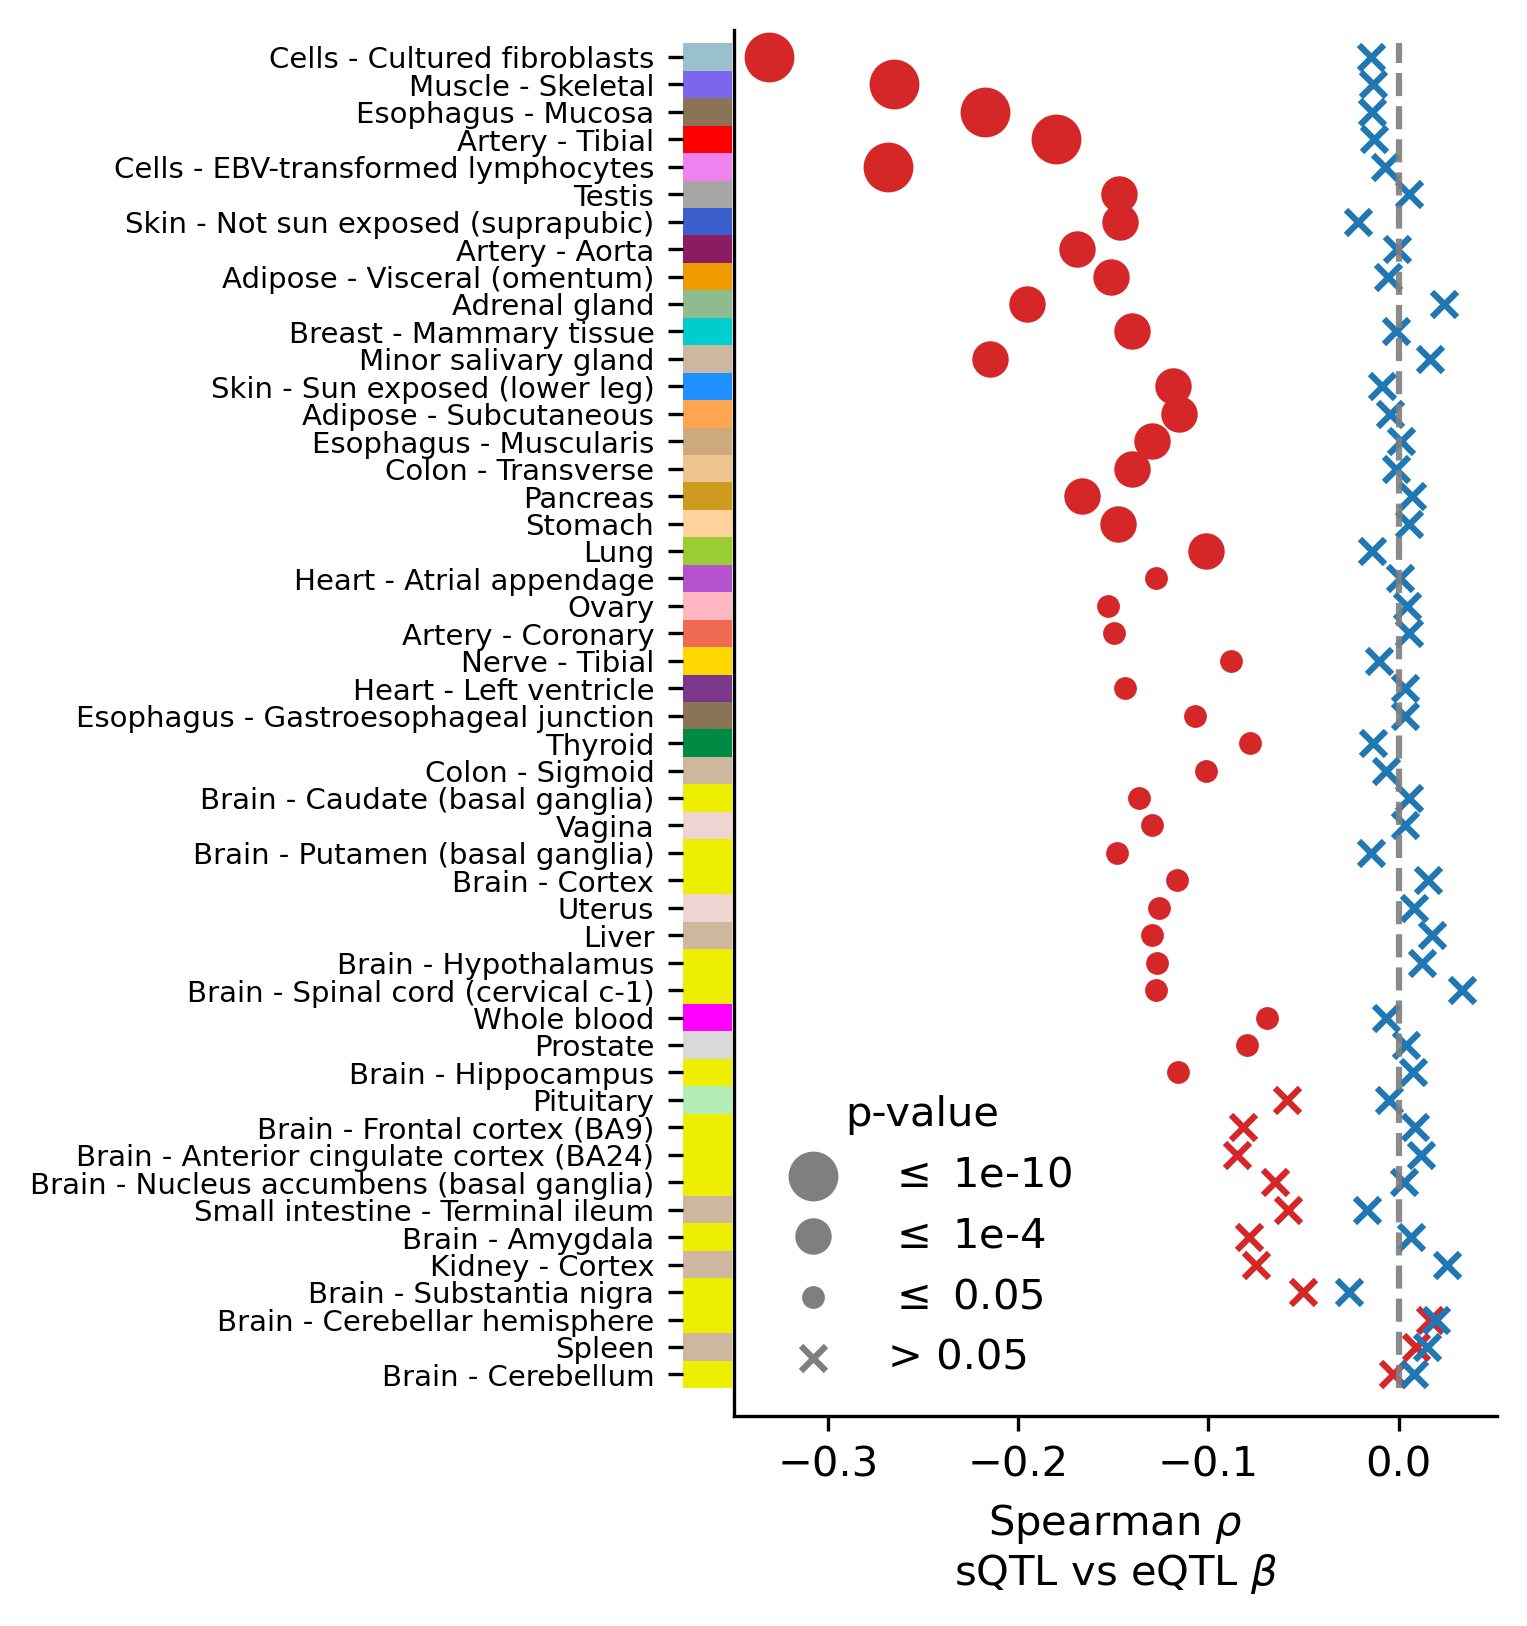

In [8]:
# Fig. 4c | fig4C -- from QTL_analysis.ipynb  (was named fig4B)
# Summary of eQTL vs sQTL effect-size comparisons across all GTEx tissues,
# separating u-sQTLs and p-sQTLs as classified by LeafCutter2. Two-sided
# Spearman correlation computed separately in each of 49 tissues. Exact
# per-tissue n, donor count and test statistics -> Supplementary Table 9.

plot_fig4C(fig4C_data)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4C.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4C.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4C.svg', dpi=300, bbox_inches='tight')

**Fig. 4c legend.** Spearman's ρ between sQTL and eQTL effect size, computed
separately in each of 49 GTEx tissues for u-sQTLs (red) and p-sQTLs (blue); each
point is one tissue, ordered by u-sQTL *P* value, with the GTEx tissue colour at
left. Within a tissue, ρ was computed across intron–variant–gene triplets
(u-sQTL, n = 129 to 1,852 triplets; p-sQTL, n = 540 to 6,032), mapped in 73 to
706 donors per tissue (median 233); donors are biological replicates, each
contributing one tissue sample, one library and one genotype, with no technical
replication. Exact per-tissue n, donor count, ρ, *t*, d.f., two-sided *P* and 95%
CI are given in Source Data. Association was tested by two-sided Spearman rank
correlation with no adjustment for multiple comparisons across tissues; marker
size denotes the u-sQTL *P* value (≤ 1 × 10⁻¹⁰, 5 tissues; ≤ 1 × 10⁻⁴, 14;
≤ 0.05, 19; > 0.05, 11, drawn as crosses).

In [9]:
# fig4C reporting -- per-tissue Source Data table (49 tissues x 2 sQTL classes).
# Written to figure_data/fig4C_source_data.tsv by run_all().
print(fig4C_source_data.head(4).to_string(index=False))
print('...')
print('rows:', len(fig4C_source_data),
      '| tissues:', fig4C_source_data.tissue.nunique(),
      '| donors per tissue:', fig4C_source_data.n_donors.min(), '-',
      fig4C_source_data.n_donors.max(),
      '(median', int(fig4C_source_data.n_donors.median()), ')')
for cls, sub in fig4C_source_data.groupby('sqtl_class'):
    print(f'  {cls}: n_pairs {sub.n_pairs.min()}-{sub.n_pairs.max()}, '
          f'{(sub.exact_two_sided_P <= 0.05).sum()}/{len(sub)} tissues at P <= 0.05')

                  tissue                   sqtl_class  n_donors  n_pairs  spearman_rho         t   df  exact_two_sided_P  ci95_low  ci95_high
    Adipose-Subcutaneous   p-sQTL (productive intron)       581     5574     -0.004769 -0.356025 5572       7.218356e-01 -0.031019   0.021487
    Adipose-Subcutaneous u-sQTL (unproductive intron)       581     1663     -0.115403 -4.734942 1661       2.377411e-06 -0.162726  -0.067551
Adipose-Visceral_Omentum   p-sQTL (productive intron)       469     4514     -0.005809 -0.390198 4512       6.964089e-01 -0.034977   0.023369
Adipose-Visceral_Omentum u-sQTL (unproductive intron)       469     1292     -0.151135 -5.491336 1290       4.799325e-08 -0.204289  -0.097093
...
rows: 98 | tissues: 49 | donors per tissue: 73 - 706 (median 233 )
  p-sQTL (productive intron): n_pairs 540-6032, 0/49 tissues at P <= 0.05
  u-sQTL (unproductive intron): n_pairs 129-1852, 38/49 tissues at P <= 0.05


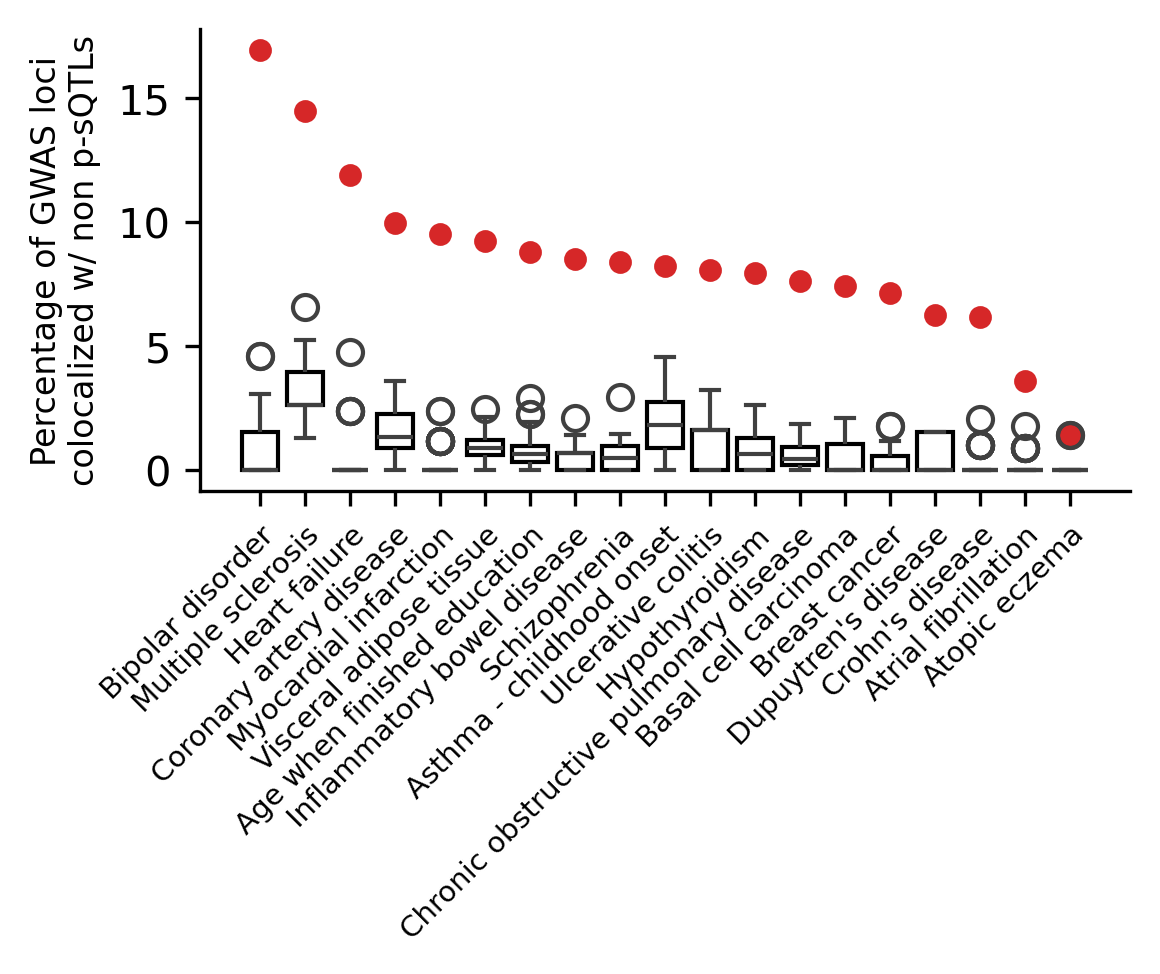

In [10]:
# Fig. 4d | fig4D -- from hyprcoloc_results.ipynb  (was named fig4D2_coloc)
# Percentage of GWAS loci colocalizing with a u-sQTL, for 19 complex traits.
# Each box summarizes n = 49 GTEx tissues, one observation per tissue. Red
# dots give the percentage of that trait's loci colocalizing in any tissue.
# 20 traits were tested; rheumatoid arthritis had no u-sQTL colocalization in
# any tissue and is therefore not depicted. Per-trait locus data ->
# Supplementary Table 10.

plot_fig4D(fig4D_data)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4D.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4D.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4D.svg', dpi=300, bbox_inches='tight')

**Fig. 4d legend.** Percentage of GWAS loci colocalizing with a u-sQTL, for
each of 19 traits. Twenty traits were tested; rheumatoid arthritis
(GCST002318, 76 loci) colocalized with a u-sQTL in no tissue and therefore has
no box. Each box summarizes n = 49 GTEx tissues, one observation per tissue;
tissues in which the trait had no u-sQTL colocalization contribute a value of
zero rather than being omitted. Centre line, median; box bounds, 25th and 75th
percentiles; whiskers, most extreme value within 1.5 × IQR of the nearer hinge;
points beyond the whiskers are plotted individually. Red dots give the
percentage of that trait's loci colocalizing in any tissue. Traits were tested
over 42 to 432 lead-SNP windows each (2,897 loci in total), using cis-QTLs
mapped in 73 to 706 donors per tissue; donors are biological replicates with no
technical replication. Study accessions, per-trait locus counts, minima, maxima
and quartiles are given in Source Data. This panel is descriptive: no statistical
test is applied and no control group is defined.

In [11]:
# fig4D reporting -- box sample sizes, GWAS accessions and per-trait Source Data.
# Written to figure_data/fig4D_source_data.tsv by run_all().
print('traits tested  :', fig4D_stats['n_traits_tested'],
      '| boxes plotted:', fig4D_stats['n_boxes'],
      '(a trait with no colocalization in any tissue gets no box)')
print('n per box      :', fig4D_stats['n_per_box'], 'GTEx tissues '
      '(tissues with no colocalization contribute a structural zero)')
print('GWAS loci total:', fig4D_stats['n_gwas_loci_total'])
print('box definition :', fig4D_stats['box_definition'])
print()

cols = ['trait_name', 'accession', 'source', 'assembly', 'n_gwas_loci_tested',
        'n_gwas_loci_colocalized', 'n_tissues_nonzero', 'in_panel']
print(fig4D_stats['per_trait'][cols].to_string(index=False))
print()

# Accessions that are project-internal release labels, not GWAS Catalog IDs.
# These still need a citation before submission.
unresolved = fig4D_stats['per_trait'].loc[
    fig4D_stats['per_trait'].accession.isin(fig4D_stats['unresolved_accessions'])]
print('NEEDS A CITATION (not GWAS Catalog accessions):')
print(unresolved[['trait_name', 'accession', 'source']].to_string(index=False))

traits tested  : 20 | boxes plotted: 19 (a trait with no colocalization in any tissue gets no box)
n per box      : 49 GTEx tissues (tissues with no colocalization contribute a structural zero)
GWAS loci total: 2897
box definition : seaborn/matplotlib boxplot defaults: centre line, median; box bounds, 25th and 75th percentiles (Q1, Q3); whiskers, most extreme value within 1.5 x IQR of the nearer hinge; points beyond the whiskers are plotted individually as outliers. Minima and maxima of each box are given in the per_trait table.

                           trait_name    accession      source assembly  n_gwas_loci_tested  n_gwas_loci_colocalized  n_tissues_nonzero  in_panel
                     Bipolar disorder      bip2021      Torino   GRCh38                  65                       11                 22      True
                   Multiple sclerosis    IMSGC2019         Ben   GRCh38                  76                       11                 49      True
                        He

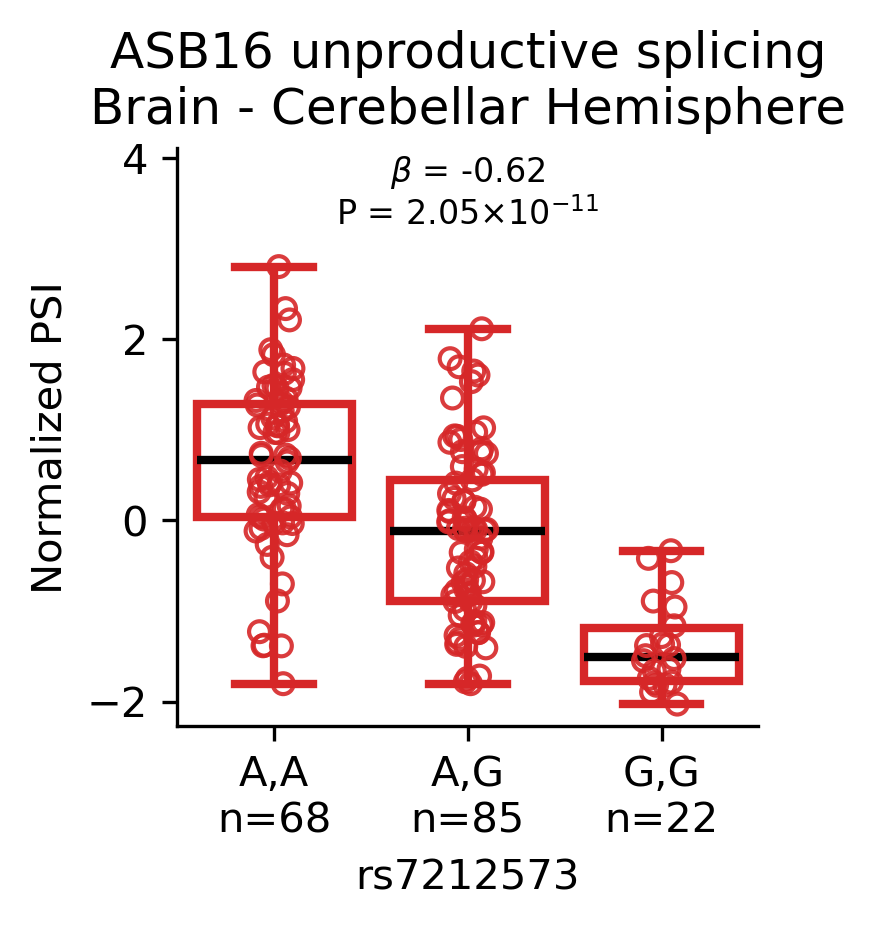

In [12]:
# Fig. 4e (left) | fig4E_sQTL -- from coloc_plots.ipynb
# Example u-sQTL colocalizing with bipolar disorder (rs7212573). The risk
# allele increases unproductive splicing of ASB16 in Brain - Cerebellar
# Hemisphere. n = 175 donors. Effect size and P from the QTLtools nominal
# pass, annotated in the Fig5D_annotated format.

ax = plot_genotype_boxplot(fig4E_sQTL_boxplot_df, color='tab:red',
                           beta=fig4E_sQTL_stats['beta'],
                           pval=fig4E_sQTL_stats['pvalue'])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4E_sQTL.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_sQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_sQTL.svg', dpi=300, bbox_inches='tight')

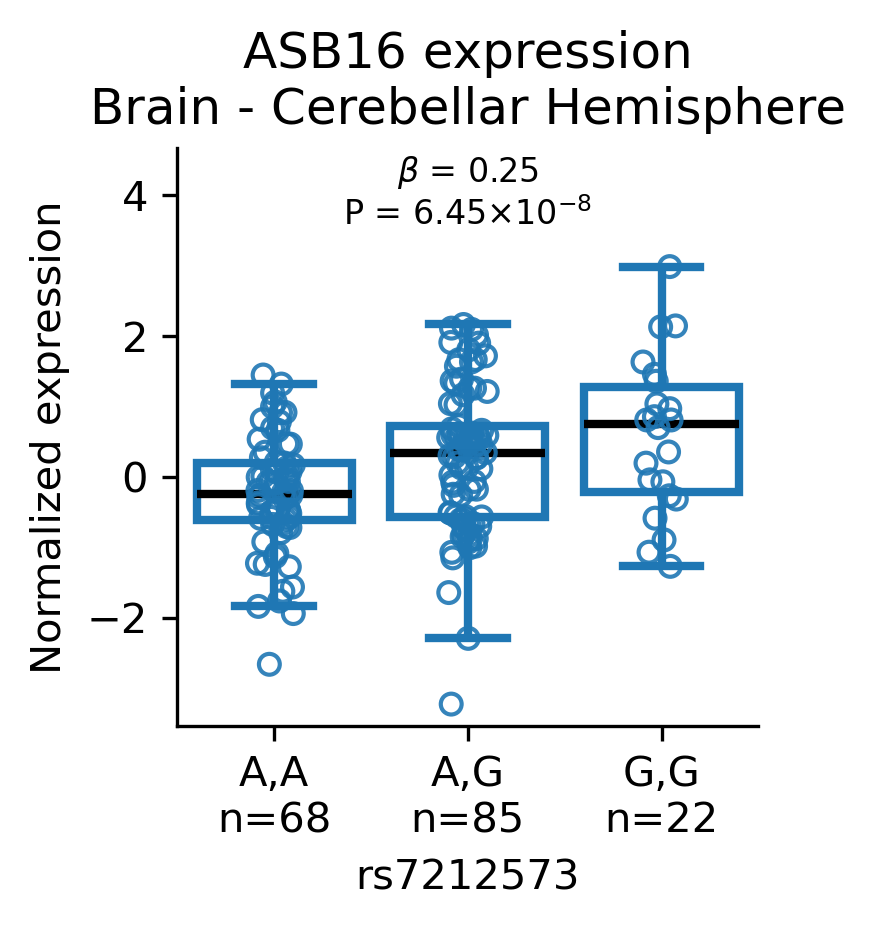

In [13]:
# Fig. 4e (right) | fig4E_eQTL -- from coloc_plots.ipynb
# The same rs7212573 allele decreases ASB16 expression in the same 175
# donors -- the opposite direction to the splicing panel, as expected if the
# unproductive isoform is degraded.

ax = plot_genotype_boxplot(fig4E_eQTL_boxplot_df, color='tab:blue',
                           beta=fig4E_eQTL_stats['beta'],
                           pval=fig4E_eQTL_stats['pvalue'])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4E_eQTL.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_eQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_eQTL.svg', dpi=300, bbox_inches='tight')

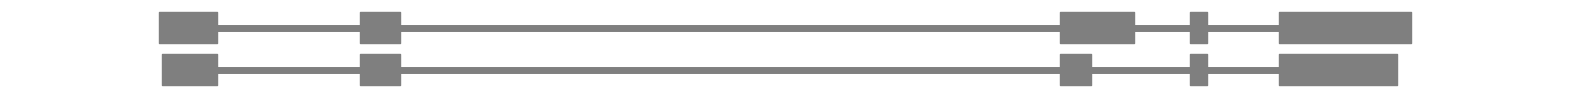

In [14]:
# Fig. 4e (gene model) | fig4E_ASB16 -- from coloc_plots.ipynb
# ASB16 transcript models for the two isoforms underlying panel e.

plot_isoform_annotations(fig4E_ASB16_annot, ASB16_GENE,
                         colores=['tab:gray'] * 2, start=None, end=None,
                         figsize=(20, 1), lwidth=5, iso_order=None)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4E_ASB16.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_ASB16.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4E_ASB16.svg', dpi=300, bbox_inches='tight')

**Fig. 4e legend** (`fig4E_sQTL`, `fig4E_eQTL`,
`fig4E_ASB16`). Normalized *ASB16* unproductive-intron
excision (left) and normalized *ASB16* expression (right) in GTEx Brain –
Cerebellar Hemisphere, grouped by genotype at rs7212573 (chr17:44176913, A>G).
n = 175 donors in both panels (A/A, n = 68; A/G, n = 85; G/G, n = 22, also given
under each genotype); donors are biological replicates, each contributing one
tissue sample, one library and one genotype, with no technical replication, and
every donor is plotted as an individual point. Centre line, median; box bounds,
25th and 75th percentiles; whiskers, most extreme value within 1.5 × IQR of the
nearer hinge; outliers are not drawn as separate markers because all data points
are shown. Effects were estimated with QTLtools under an additive linear model
and tested by two-sided *t* test on the slope; β and *P* shown on each panel are
those of the plotted variant: splicing β = −0.622 ± 0.087 s.e. (95% CI −0.793 to
−0.451), *t*(173) = −7.17, *P* = 2.05 × 10⁻¹¹; expression β = 0.246 ± 0.044 s.e.
(95% CI 0.160 to 0.332), *t*(173) = 5.65, *P* = 6.45 × 10⁻⁸. These *P* values are
nominal; correction for the number of variants tested in cis was applied at locus
selection, by a permutation pass (1,000 permutations, beta approximation) giving
adjusted *P* = 3.26 × 10⁻⁸ (Storey *q* = 3.82 × 10⁻⁶) for the intron and adjusted
*P* = 5.45 × 10⁻⁶ (*q* = 1.87 × 10⁻⁵) for the gene.

In [15]:
# fig4E panels reporting -- genotype group sizes, box statistics and QTL tests.
# beta and nominal P are at the plotted variant (rs7212573); adj. P is the
# phenotype-level permutation-adjusted P, which QTLtools reports at that
# phenotype's own top variant -- printed below so the two are not confused.
for tag, box, st in [('sQTL (splicing) ', fig4E_sQTL_box_stats, fig4E_sQTL_stats),
                     ('eQTL (expression)', fig4E_eQTL_box_stats, fig4E_eQTL_stats)]:
    print(f"--- {tag} | n = {box['n_total']} donors | plotted variant {st['variant']}")
    print(box['groups'].to_string(index=False))
    lo, hi = st['ci95']
    print(f"  beta = {st['beta']:.3f} +/- {st['beta_se']:.3f} s.e., "
          f"95% CI [{lo:.3f}, {hi:.3f}], t({st['df']}) = {st['t']:.2f}, "
          f"nominal P = {st['pvalue']:.3g}, r2 = {st['r_squared']:.3f}")
    print(f"  adj. P (annotated on panel) = {st['adj_pvalue']:.3g}, "
          f"Storey q = {st['qvalue']:.3g}, "
          f"permutation top variant = {st['perm_top_variant']}")
print()
print('box definition:', fig4E_sQTL_box_stats['box_definition'])

--- sQTL (splicing)  | n = 175 donors | plotted variant chr17_44176913_A_G_b38
genotype  n    median        q1        q3  whisker_low  whisker_high       min       max
     A,A 68  0.666287  0.038161  1.288520    -1.801731      2.801609 -1.801731  2.801609
     A,G 85 -0.112832 -0.893215  0.447798    -1.801731      2.115287 -1.801731  2.115287
     G,G 22 -1.508546 -1.774645 -1.192359    -2.026844     -0.334247 -2.026844 -0.334247
  beta = -0.622 +/- 0.087 s.e., 95% CI [-0.793, -0.451], t(173) = -7.17, nominal P = 2.05e-11, r2 = 0.229
  adj. P (annotated on panel) = 3.26e-08, Storey q = 3.82e-06, permutation top variant = chr17_44173727_T_C_b38
--- eQTL (expression) | n = 175 donors | plotted variant chr17_44176913_A_G_b38
genotype  n    median        q1       q3  whisker_low  whisker_high      min     max
     A,A 68 -0.243465 -0.619115 0.197788     -1.84101       1.31689 -2.66320 1.44547
     A,G 85  0.344530 -0.570050 0.725200     -2.29486       2.16294 -3.22838 2.16294
     G,G 22 

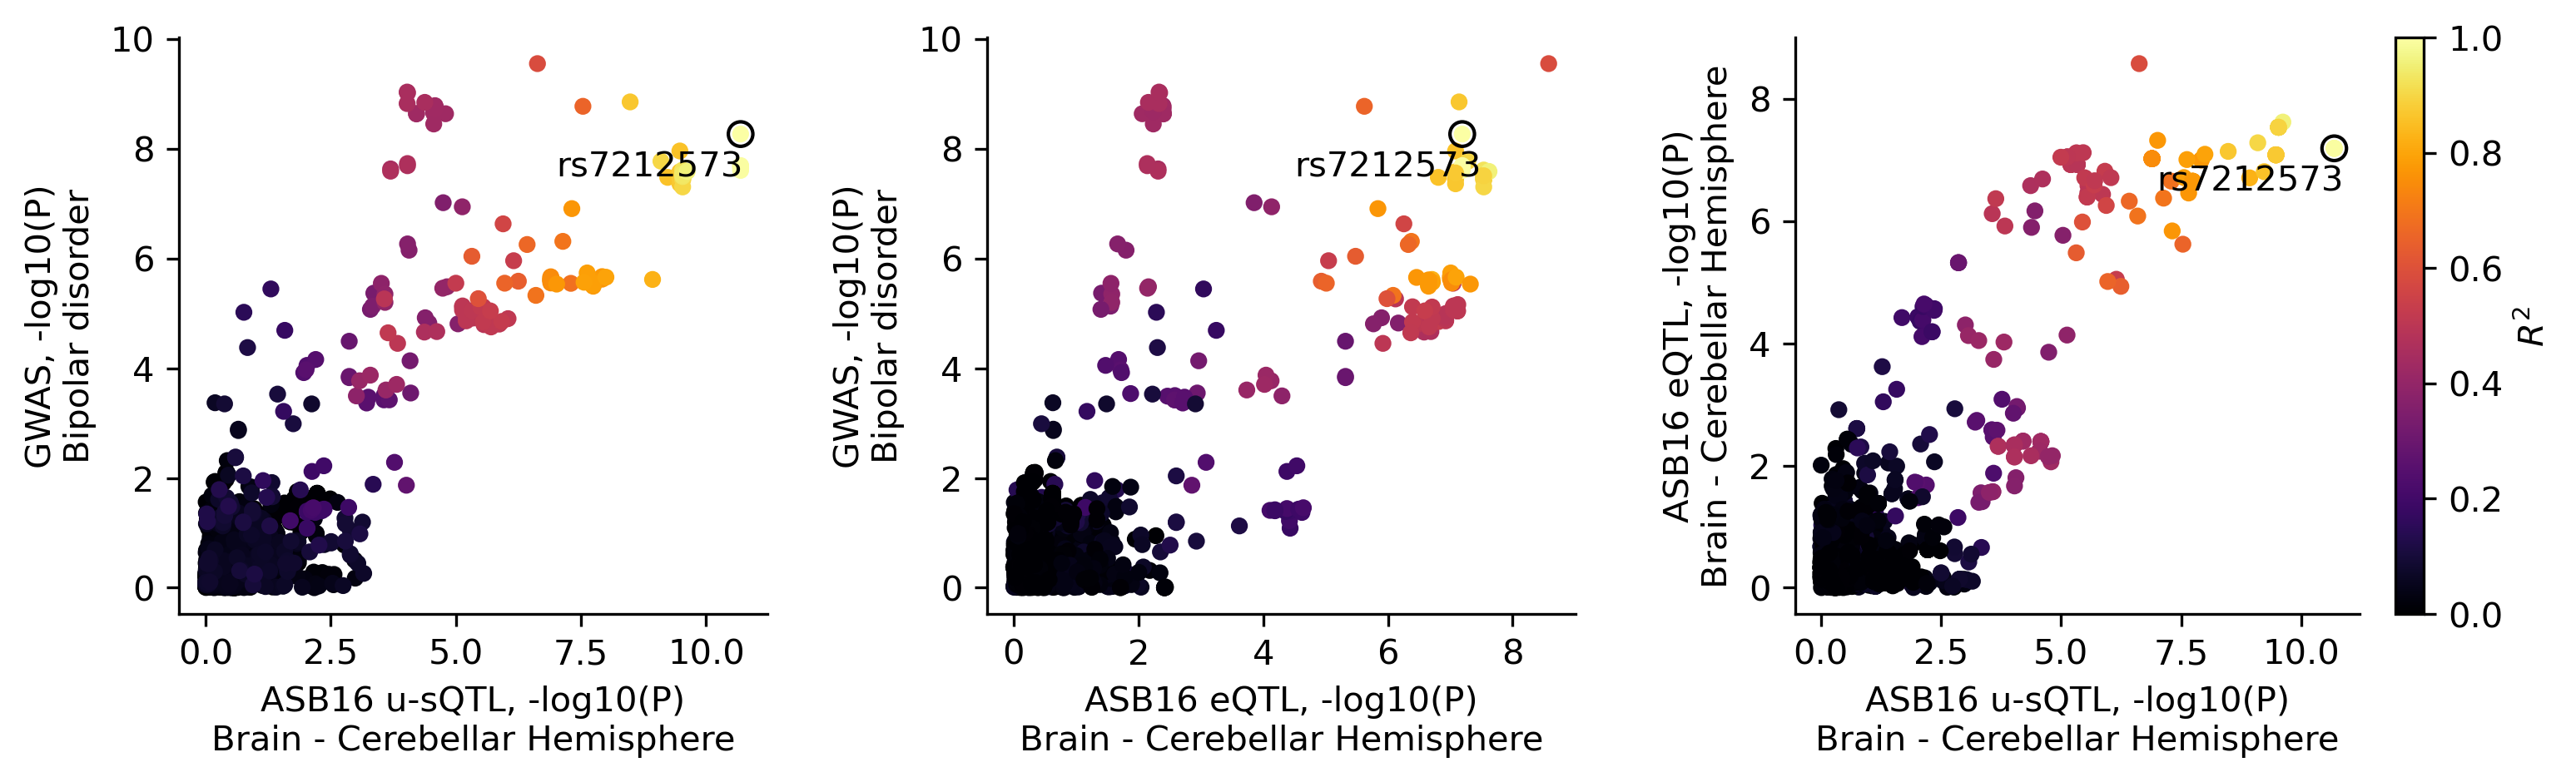

In [16]:
# Fig. 4f | fig4F -- from Fig4_example.ipynb
# LocusCompare plots showing colocalization of the GWAS association, eQTL and
# u-sQTL at ASB16. QTL P values are from the QTLtools nominal pass; GWAS P
# values are uncorrected, from public summary statistics. Points are coloured
# by r^2 with rs7212573, which is ringed in black.
#
# NOTE: Fig4_example.ipynb intersects only the four tables plotted here, while
# coloc_plots.ipynb builds the same panel intersecting several further tissues,
# which yields a smaller SNP set. This follows Fig4_example.ipynb.

plot_fig4F_locuscompare(fig4F_data)

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4F.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4F.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4F.svg', dpi=300, bbox_inches='tight')

# Original destination in Fig4_example.ipynb (commented out there):
# plt.savefig('../code/plots/fig4_coloc_example.png', dpi=300, bbox_inches='tight')

**Not a Figure 4 panel** (`fig4_colocs_sc2`). Effect of each sQTL on
excision of the productive intron (β, *x* axis) against its effect on host-gene
expression (β, *y* axis), for the productive introns of GWAS-colocalizing PR,UP
clusters. Each point is one intron–variant–gene triplet, not a replicate: n = 112
productive introns, from 102 clusters in 33 genes, spanning 34 GTEx tissues and
15 GWAS traits (36 loci). The underlying cis-QTLs were mapped in 129 to 706
donors per tissue (median 370); donors are biological replicates, each
contributing one tissue sample, one library and one genotype, with no technical
replication. Dashed line, slope = Spearman's ρ of the full sample with intercept
= mean of the *y* values (not a least-squares fit); shaded band, 10th–90th
percentile of ρ over 100 random subsamples of 100 points — a dispersion band at
an arbitrary n, not a confidence interval. Association was tested by two-sided
Spearman rank correlation, without adjustment for multiple comparisons as the
panel is a single test: ρ = 0.362 (95% CI 0.183 to 0.517), *t*(110) = 4.07,
*P* = 8.81 × 10⁻⁵.

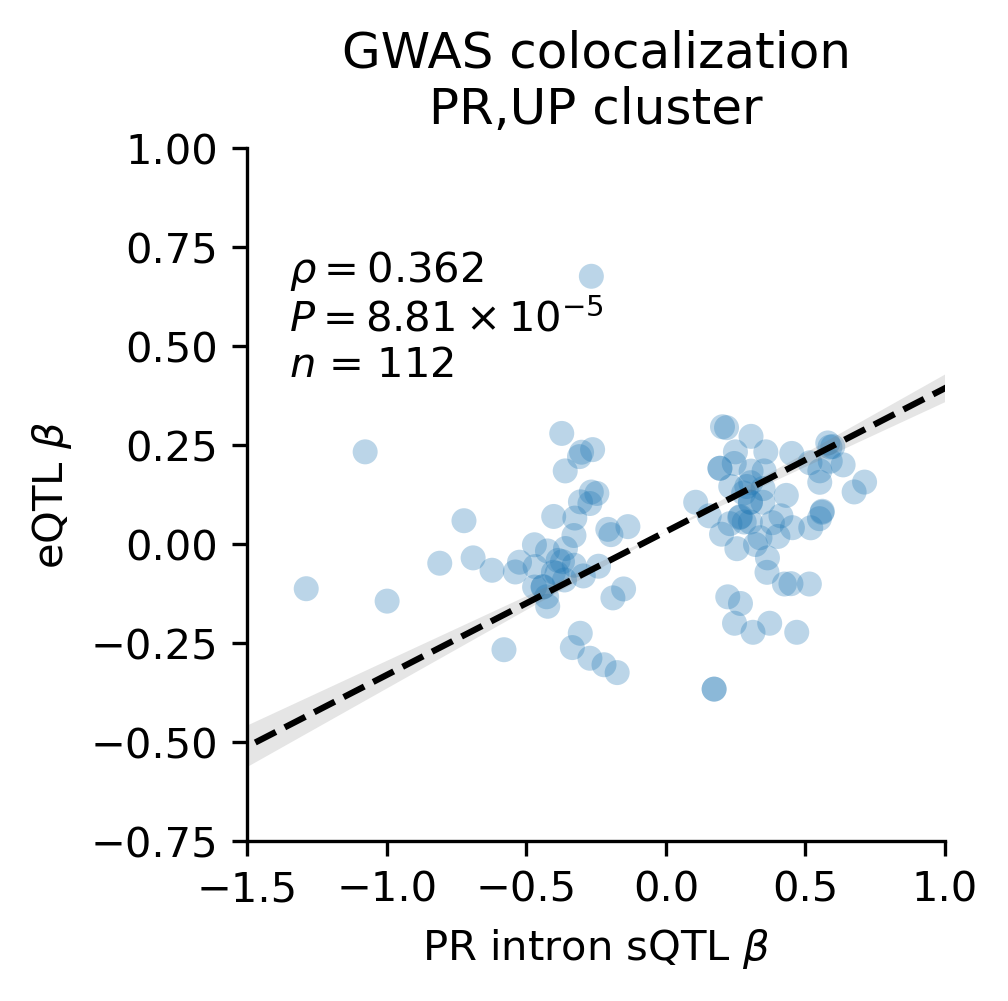

In [17]:
# NOT A FIGURE 4 PANEL | fig4_colocs_sc2 -- from hyprcoloc_results.ipynb
# PR introns of GWAS-colocalizing PR,UP clusters. hyprcoloc_results.ipynb carries
# a commented-out fig4B1 savefig on this plot and writes it as fig4_colocs_sc2;
# kept here for completeness but not part of the published Figure 4.
from Figure4_helpers import make_rho_stats

fig4b1_coloc_stats = make_rho_stats(fig4_colocs_sc2_fit['x'], fig4_colocs_sc2_fit['y'], seed=0)

plot_beta_scatter(
    fig4_colocs_sc2_fit,
    color='tab:blue',
    xlim=[-1.5, 1],
    ylim=[-0.75, 1],
    text=r'$\rho = 0.36$' + '\np-val $< 1e^{-4}$',   # original, superseded by stats=
    stats=fig4b1_coloc_stats,
    text_xy=(-1.35, 0.4),
    xlabel=r'PR intron sQTL $\beta$',
    ylabel=r'eQTL $\beta$',
    title='GWAS colocalization\nPR,UP cluster',
    alpha=0.3,
    x_fit=(-2, 2),
)

# NOTE: in hyprcoloc_results.ipynb this panel also carried a commented-out
# fig4B1 savefig. It is deliberately NOT enabled here -- it would overwrite
# the fig4B1 written by the cell above. This panel saves as fig4_colocs_sc2.
# plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{PLOTS_DIR}/fig4B_usQTL.svg', dpi=300, bbox_inches='tight')

unrasterize()
plt.savefig(f'{PLOTS_DIR}/fig4_colocs_sc2.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4_colocs_sc2.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PLOTS_DIR}/fig4_colocs_sc2.svg', dpi=300, bbox_inches='tight')

In [18]:
# fig4_colocs_sc2 reporting -- the numbers quoted in the legend above.
lo, hi = fig4b1_coloc_stats['ci95']
print(f"fig4_colocs_sc2 (PR introns of GWAS-colocalizing PR,UP clusters): "
      f"n = {fig4b1_coloc_stats['n']} triplets | "
      f"rho = {fig4b1_coloc_stats['rho']:.3f} (95% CI {lo:.3f} to {hi:.3f}) | "
      f"t({fig4b1_coloc_stats['df']}) = {fig4b1_coloc_stats['t']:.2f} | "
      f"P = {fig4b1_coloc_stats['pvalue']:.3g}")
blo, bhi = fig4b1_coloc_stats['ci95_boot']
print(f"    bootstrap 95% CI {blo:.3f} to {bhi:.3f} (should match the Fisher-z CI)")

# Panel composition quoted in the legend, from the same rows make_coloc_pr_fit selects.
from Figure4_helpers import load_up_results

_sel = load_up_results()
_sel = _sel.loc[(_sel.distance_abs <= 1000) & (_sel.itype == 'PR') & (_sel.PSI >= 0)]
print(f"    {_sel.intron.nunique()} introns, {_sel.cluster.nunique()} clusters, "
      f"{_sel.gene.nunique()} genes, {_sel.tissue.nunique()} tissues, "
      f"{_sel.gwas_trait.nunique()} GWAS traits, {_sel.gwas_loci.nunique()} loci")

fig4_colocs_sc2 (PR introns of GWAS-colocalizing PR,UP clusters): n = 112 triplets | rho = 0.362 (95% CI 0.183 to 0.517) | t(110) = 4.07 | P = 8.81e-05
    bootstrap 95% CI 0.194 to 0.515 (should match the Fisher-z CI)
    112 introns, 102 clusters, 33 genes, 34 tissues, 15 GWAS traits, 36 loci
